In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [20]:
df=pd.read_csv(r"C:\Users\Nishant Pandey\OneDrive\Desktop\Social Media Reach Analysis\Social_Media_Reach_Analysis_NovaTech.csv")

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [22]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(r"C:\Users\Nishant Pandey\OneDrive\Desktop\Social Media Reach Analysis\Social_Media_Reach_Analysis_NovaTech.csv")

print("="*60)
print("First 5 Rows")
print("="*60)
print(df.head())

print("\nDataset Shape :", df.shape)

First 5 Rows
         Date   Company  Platform  Impressions  Reach  Engagements  Likes  \
0  2025-01-01  NovaTech  Facebook        28010  18735         4935   3914   
1  2025-01-02  NovaTech   YouTube        33938  31370         3689   2491   
2  2025-01-03  NovaTech         X        38068  30220         4693   3346   
3  2025-01-04  NovaTech  Facebook        41429  35958         3537   2380   
4  2025-01-05  NovaTech  Facebook        36404  27351          434    233   

   Comments  Shares  Clicks  Conversions  Ad_Spend_USD  Revenue_USD  
0       720     721    1976          150        816.07      5470.80  
1       233     357    2718           40        887.42      2356.85  
2       362     778    2154          145        207.01      2431.72  
3       438     339     693          187        139.95      3832.77  
4        35      38    1128           71        595.53       733.72  

Dataset Shape : (180, 13)


In [23]:
# ==========================================================
# Dataset Information
# ==========================================================

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          180 non-null    object 
 1   Company       180 non-null    object 
 2   Platform      180 non-null    object 
 3   Impressions   180 non-null    int64  
 4   Reach         180 non-null    int64  
 5   Engagements   180 non-null    int64  
 6   Likes         180 non-null    int64  
 7   Comments      180 non-null    int64  
 8   Shares        180 non-null    int64  
 9   Clicks        180 non-null    int64  
 10  Conversions   180 non-null    int64  
 11  Ad_Spend_USD  180 non-null    float64
 12  Revenue_USD   180 non-null    float64
dtypes: float64(2), int64(8), object(3)
memory usage: 18.4+ KB
None

Statistical Summary
        Impressions         Reach  Engagements        Likes    Comments  \
count    180.000000    180.000000   180.000000   180.000000  180.

In [24]:
# ==========================================================
# Data Cleaning
# ==========================================================

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print("\nDataset Shape After Cleaning :", df.shape)


Dataset Shape After Cleaning : (180, 13)


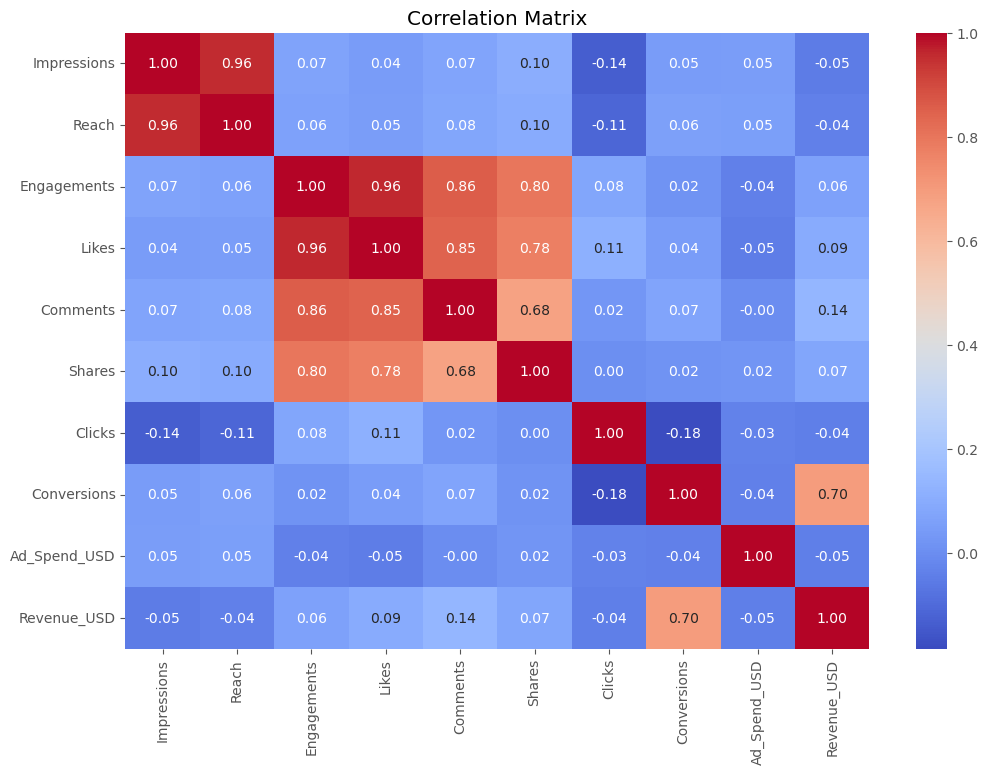

In [25]:
# ==========================================================
# Correlation Matrix
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

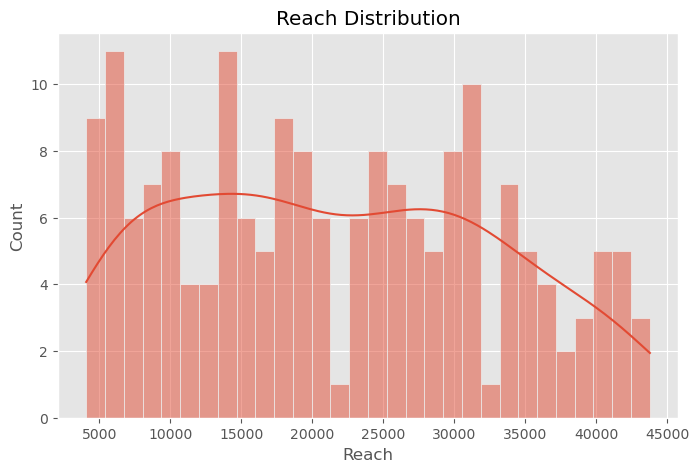

In [26]:
# ==========================================================
# Reach Distribution
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Reach"], bins=30, kde=True)
plt.title("Reach Distribution")
plt.xlabel("Reach")
plt.show()


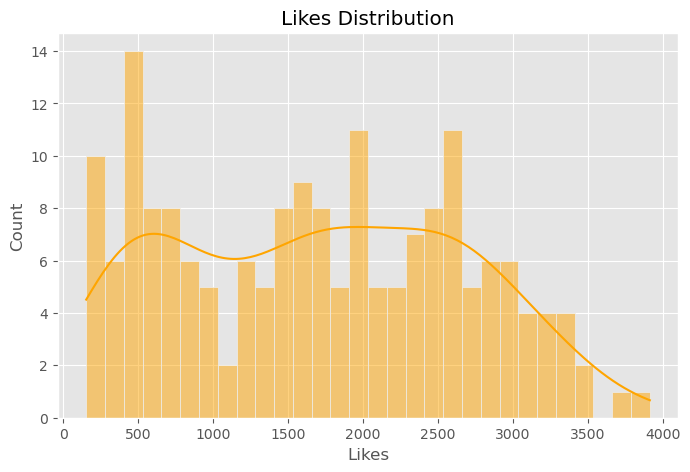

In [27]:
# ==========================================================
# Likes Distribution
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Likes"], bins=30, color="orange", kde=True)
plt.title("Likes Distribution")
plt.show()


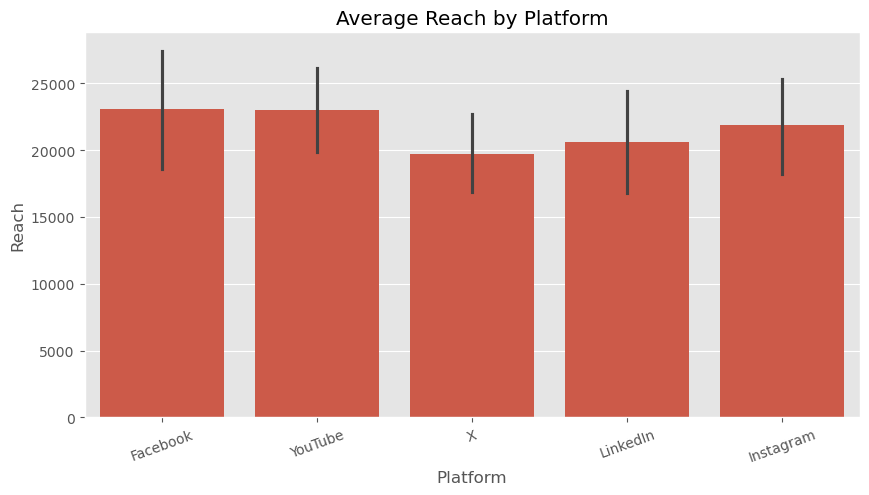

In [28]:
# ==========================================================
# Average Reach by Platform
# ==========================================================

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Platform", y="Reach")
plt.title("Average Reach by Platform")
plt.xticks(rotation=20)
plt.show()


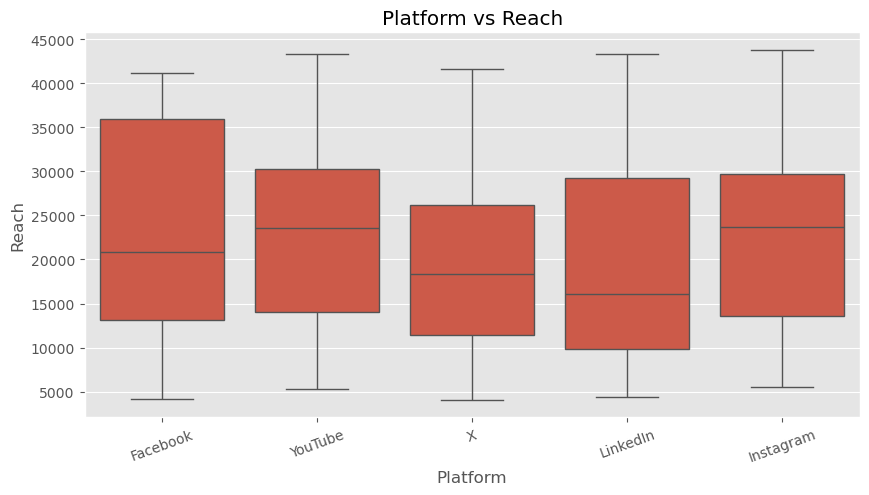

In [30]:
# ==========================================================
# Platform-wise Boxplot
# ==========================================================

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Platform", y="Reach")
plt.title("Platform vs Reach")
plt.xticks(rotation=20)
plt.show()


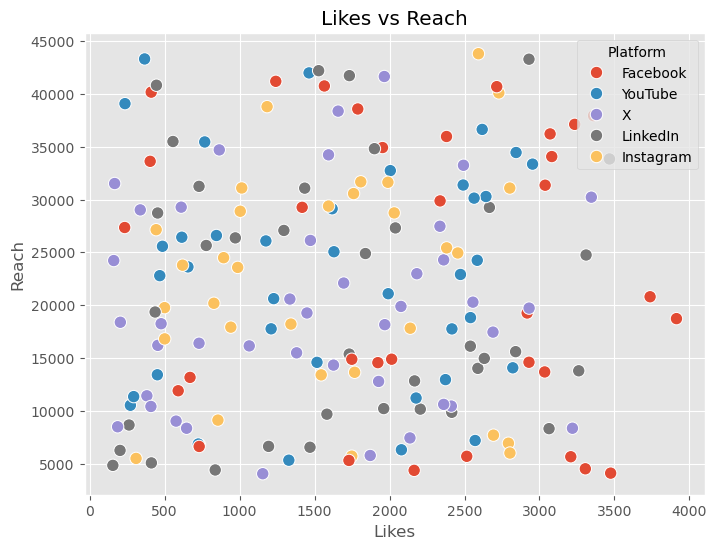

In [31]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Likes",
    y="Reach",
    hue="Platform",
    s=80
)
plt.title("Likes vs Reach")
plt.show()


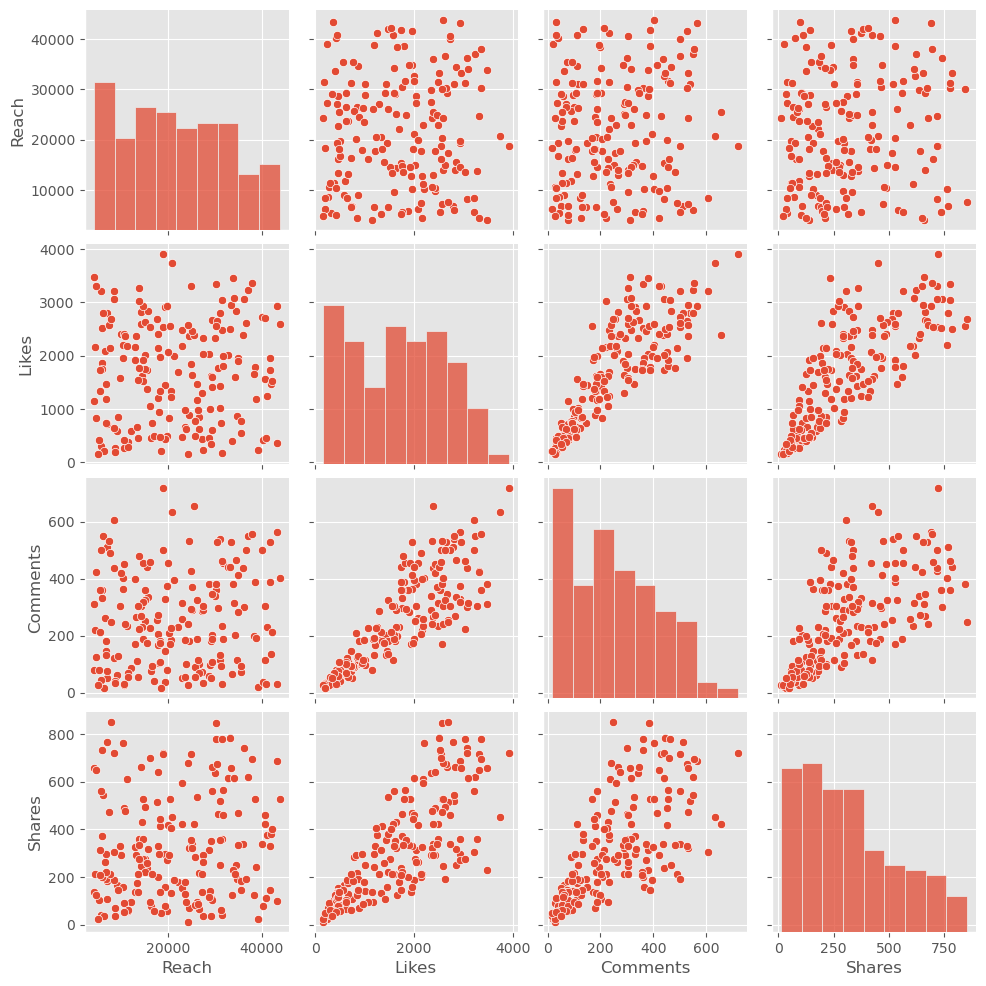

In [32]:
# ==========================================================
# Pair Plot
# ==========================================================

sns.pairplot(df[["Reach","Likes","Comments","Shares"]])
plt.show()


In [33]:
# ==========================================================
# Engagement Rate
# ==========================================================

df["Engagement Rate"] = (
    df["Likes"] +
    df["Comments"] +
    df["Shares"]
) / df["Reach"]

print("\nEngagement Rate")
print(df[["Engagement Rate"]].head())


Engagement Rate
   Engagement Rate
0         0.285829
1         0.098215
2         0.148445
3         0.087797
4         0.011188


In [34]:
# ==========================================================
# Top 10 Performing Posts
# ==========================================================

top_posts = df.sort_values(by="Reach", ascending=False)

print("\nTop 10 Posts")
print(top_posts.head(10))


Top 10 Posts
           Date   Company   Platform  Impressions  Reach  Engagements  Likes  \
145  2025-05-26  NovaTech  Instagram        47355  43787         4552   2593   
25   2025-01-26  NovaTech    YouTube        46563  43294          568    366   
45   2025-02-15  NovaTech   LinkedIn        49285  43268         4078   2930   
178  2025-06-28  NovaTech   LinkedIn        48610  42183         2077   1527   
177  2025-06-27  NovaTech    YouTube        48356  41974         2219   1463   
128  2025-05-09  NovaTech   LinkedIn        48572  41713         2729   1732   
133  2025-05-14  NovaTech          X        49079  41631         3755   1965   
122  2025-05-03  NovaTech   Facebook        44918  41178         1944   1241   
123  2025-05-04  NovaTech   LinkedIn        44449  40807          629    445   
109  2025-04-20  NovaTech   Facebook        46900  40737         2168   1565   

     Comments  Shares  Clicks  Conversions  Ad_Spend_USD  Revenue_USD  \
145       404     525    2590   

In [35]:
# ==========================================================
# Platform-wise Average Engagement
# ==========================================================

engagement = df.groupby("Platform")[["Likes","Comments","Shares"]].mean()

print("\nAverage Engagement by Platform")
print(engagement)


Average Engagement by Platform
                 Likes    Comments      Shares
Platform                                      
Facebook   2207.121212  320.090909  413.060606
Instagram  1555.500000  262.250000  322.125000
LinkedIn   1676.243243  249.675676  298.918919
X          1498.829268  222.268293  261.170732
YouTube    1607.675676  233.891892  335.378378


In [37]:
# ==========================================================
# Best Posting Time
# ==========================================================

if "Posting Time" in df.columns:

    print("\nBest Posting Time")

    print(
        df.groupby("Posting Time")["Reach"]
        .mean()
        .sort_values(ascending=False)
    )


In [38]:
# ==========================================================
# Day-wise Reach
# ==========================================================

if "Day" in df.columns:

    plt.figure(figsize=(10,5))

    sns.barplot(data=df, x="Day", y="Reach")

    plt.title("Average Reach by Day")

    plt.xticks(rotation=30)

    plt.show()


In [39]:
# ==========================================================
# Basic Statistics
# ==========================================================

print("\nAverage Reach :", df["Reach"].mean())

print("Maximum Reach :", df["Reach"].max())

print("Minimum Reach :", df["Reach"].min())

print("Median Reach :", df["Reach"].median())


Average Reach : 21571.316666666666
Maximum Reach : 43787
Minimum Reach : 4069
Median Reach : 20439.5


In [40]:
# ==========================================================
# Machine Learning Model
# ==========================================================

X = df[["Likes","Comments","Shares"]]
y = df["Reach"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_test)


In [41]:
# ==========================================================
# Model Evaluation
# ==========================================================

print("\nMachine Learning Performance")

print("MAE :", mean_absolute_error(y_test, prediction))

print("MSE :", mean_squared_error(y_test, prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

print("R2 Score :", r2_score(y_test, prediction))


Machine Learning Performance
MAE : 8459.527389370349
MSE : 105174927.5011322
RMSE : 10255.48280195195
R2 Score : 0.033383468784336845



Actual vs Predicted
     Actual Reach  Predicted Reach
19          29126     21389.823618
42          21092     21924.689111
153         10626     21477.118585
78          13426     20941.699853
145         43787     22476.312810
15          19269     21015.650299
24          18832     23734.610442
68          31675     23622.124187
113         18220     21803.533683
118          4860     20684.738252


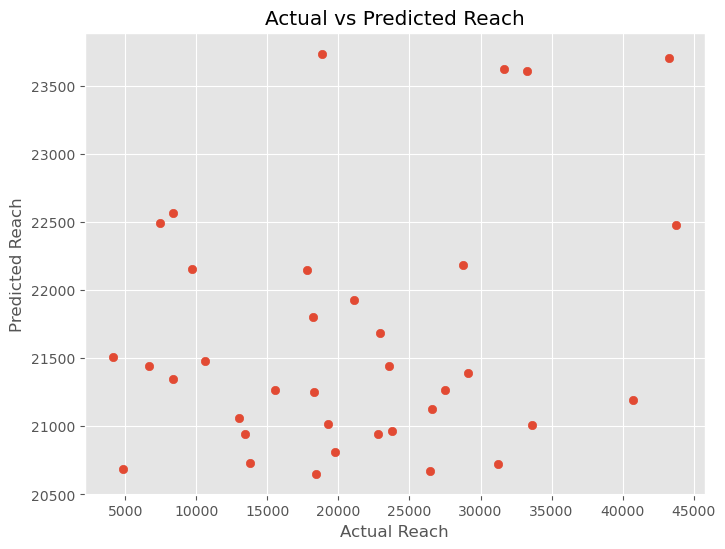

In [42]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison = pd.DataFrame({
    "Actual Reach": y_test,
    "Predicted Reach": prediction
})

print("\nActual vs Predicted")
print(comparison.head(10))

plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Reach")

plt.ylabel("Predicted Reach")

plt.title("Actual vs Predicted Reach")

plt.grid(True)

plt.show()

In [43]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

df.to_csv("Processed_Social_Media_Reach.csv", index=False)

print("\nProcessed Dataset Saved Successfully.")

print("\nProject Completed Successfully.")


Processed Dataset Saved Successfully.

Project Completed Successfully.
